# Tox21 Ensemble Stacking (Phase 3.5)

Build a two-stage ensemble where 12 assay-specific XGBoost model outputs become meta-features for a calibrated logistic regression meta-model.

## Cell 1 - Imports and Setup

In [15]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import json
import os
import sys
from pathlib import Path

try:
    from app.services.mol_processor import extract_features
except ModuleNotFoundError:
    backend_dir = str(Path.cwd().resolve().parents[1])
    if backend_dir not in sys.path:
        sys.path.append(backend_dir)
    from app.services.mol_processor import extract_features

ASSAY_COLUMNS = [
    'NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER',
    'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53'
]
MODELS_DIR = '../trained_models/'
RANDOM_STATE = 42

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs('../processed', exist_ok=True)
os.makedirs('../../../docs', exist_ok=True)


def load_core_data() -> tuple[np.ndarray, pd.DataFrame]:
    """Load base feature matrix and assay label dataframe."""
    X_local = np.load('../processed/X_processed.npy')
    y_local = pd.read_parquet('../processed/y_labels.parquet')
    return X_local, y_local


def load_base_models(assay_columns: list[str], models_dir: str) -> dict[str, object]:
    """Load all base assay models from disk."""
    models = {}
    for assay in assay_columns:
        model_path = f'{models_dir}model_{assay}.joblib'
        if not os.path.exists(model_path):
            raise FileNotFoundError(f'Missing base model for assay {assay}: {model_path}')
        models[assay] = joblib.load(model_path)
    return models


def build_meta_labels(y_df: pd.DataFrame, assay_columns: list[str]) -> np.ndarray:
    """Create overall binary toxicity label: 1 if any tested assay is toxic, else 0, NaN if all missing."""
    y_view = y_df[assay_columns]

    def row_to_meta(row: pd.Series) -> float:
        valid = row.dropna()
        if valid.empty:
            return np.nan
        return float((valid == 1).any())

    return y_view.apply(row_to_meta, axis=1).to_numpy(dtype=float)


print('Setup complete.')

Setup complete.


## Cell 2 - Build Meta-Features Matrix

In [16]:
print('Loading data and base models...')
X, y = load_core_data()
base_models = load_base_models(ASSAY_COLUMNS, MODELS_DIR)

# Build stacking feature matrix: each column is one assay model probability.
meta_features_full = np.zeros((len(X), len(ASSAY_COLUMNS)), dtype=np.float32)

for assay_idx, assay in enumerate(ASSAY_COLUMNS):
    model = base_models[assay]
    probs = model.predict_proba(X)[:, 1].astype(np.float32)
    meta_features_full[:, assay_idx] = probs

    valid_count = int((~y[assay].isna()).sum())
    print(f'  Added meta-feature for {assay}: valid labels={valid_count}, probs_shape={probs.shape}')

meta_features_df = pd.DataFrame(meta_features_full, columns=ASSAY_COLUMNS)
np.save('../processed/meta_features_full.npy', meta_features_full)

print(f'\nMeta-features complete: {meta_features_full.shape}')
print('Saved: ../processed/meta_features_full.npy')

Loading data and base models...
  Added meta-feature for NR-AR: valid labels=7265, probs_shape=(7831,)
  Added meta-feature for NR-AR-LBD: valid labels=6758, probs_shape=(7831,)
  Added meta-feature for NR-AhR: valid labels=6549, probs_shape=(7831,)
  Added meta-feature for NR-Aromatase: valid labels=5821, probs_shape=(7831,)
  Added meta-feature for NR-ER: valid labels=6193, probs_shape=(7831,)
  Added meta-feature for NR-ER-LBD: valid labels=6955, probs_shape=(7831,)
  Added meta-feature for NR-PPAR-gamma: valid labels=6450, probs_shape=(7831,)
  Added meta-feature for SR-ARE: valid labels=5832, probs_shape=(7831,)
  Added meta-feature for SR-ATAD5: valid labels=7072, probs_shape=(7831,)
  Added meta-feature for SR-HSE: valid labels=6467, probs_shape=(7831,)
  Added meta-feature for SR-MMP: valid labels=5810, probs_shape=(7831,)
  Added meta-feature for SR-p53: valid labels=6774, probs_shape=(7831,)

Meta-features complete: (7831, 12)
Saved: ../processed/meta_features_full.npy


## Cell 3 - Create Overall Toxicity Label for Meta-Model

In [17]:
if 'meta_features_full' not in globals():
    X, y = load_core_data()
    if os.path.exists('../processed/meta_features_full.npy'):
        meta_features_full = np.load('../processed/meta_features_full.npy')
    else:
        base_models = load_base_models(ASSAY_COLUMNS, MODELS_DIR)
        meta_features_full = np.column_stack([
            base_models[assay].predict_proba(X)[:, 1] for assay in ASSAY_COLUMNS
        ]).astype(np.float32)

y_meta_raw = build_meta_labels(y, ASSAY_COLUMNS)
meta_train_mask = ~np.isnan(y_meta_raw)

meta_features = meta_features_full[meta_train_mask]
y_meta = y_meta_raw[meta_train_mask].astype(int)

class_counts = np.bincount(y_meta)
print(f'Meta training samples: {len(y_meta)}')
print(f'Safe (0): {class_counts[0]} | Toxic (1): {class_counts[1]}')
print(f'Meta feature shape (trainable subset): {meta_features.shape}')

Meta training samples: 7831
Safe (0): 4959 | Toxic (1): 2872
Meta feature shape (trainable subset): (7831, 12)


## Cell 4 - Train Meta-Model with 5-Fold OOF Cross-Validation

In [18]:
if 'meta_features' not in globals() or 'y_meta' not in globals():
    X, y = load_core_data()
    if os.path.exists('../processed/meta_features_full.npy'):
        meta_features_full = np.load('../processed/meta_features_full.npy')
    else:
        base_models = load_base_models(ASSAY_COLUMNS, MODELS_DIR)
        meta_features_full = np.column_stack([
            base_models[assay].predict_proba(X)[:, 1] for assay in ASSAY_COLUMNS
        ]).astype(np.float32)

    y_meta_raw = build_meta_labels(y, ASSAY_COLUMNS)
    meta_train_mask = ~np.isnan(y_meta_raw)
    meta_features = meta_features_full[meta_train_mask]
    y_meta = y_meta_raw[meta_train_mask].astype(int)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_predictions = np.zeros(len(meta_features), dtype=np.float32)

for fold, (train_idx, val_idx) in enumerate(kf.split(meta_features, y_meta), start=1):
    X_fold_train = meta_features[train_idx]
    y_fold_train = y_meta[train_idx]
    X_fold_val = meta_features[val_idx]

    meta_clf = LogisticRegression(
        C=1.0,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        max_iter=1000
    )
    meta_clf.fit(X_fold_train, y_fold_train)
    oof_predictions[val_idx] = meta_clf.predict_proba(X_fold_val)[:, 1]

    fold_auc = roc_auc_score(y_meta[val_idx], oof_predictions[val_idx])
    print(f'Fold {fold} ROC-AUC: {fold_auc:.4f}')

meta_auc = roc_auc_score(y_meta, oof_predictions)
print(f'\nMeta-model OOF ROC-AUC: {meta_auc:.4f}')

Fold 1 ROC-AUC: 0.9153
Fold 2 ROC-AUC: 0.9133
Fold 3 ROC-AUC: 0.9130
Fold 4 ROC-AUC: 0.9198
Fold 5 ROC-AUC: 0.9200

Meta-model OOF ROC-AUC: 0.9163


## Cell 5 - Train Final Calibrated Meta-Model

In [19]:
if 'meta_features' not in globals() or 'y_meta' not in globals():
    X, y = load_core_data()
    if os.path.exists('../processed/meta_features_full.npy'):
        meta_features_full = np.load('../processed/meta_features_full.npy')
    else:
        base_models = load_base_models(ASSAY_COLUMNS, MODELS_DIR)
        meta_features_full = np.column_stack([
            base_models[assay].predict_proba(X)[:, 1] for assay in ASSAY_COLUMNS
        ]).astype(np.float32)

    y_meta_raw = build_meta_labels(y, ASSAY_COLUMNS)
    meta_train_mask = ~np.isnan(y_meta_raw)
    meta_features = meta_features_full[meta_train_mask]
    y_meta = y_meta_raw[meta_train_mask].astype(int)

final_meta = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    max_iter=1000
)
final_meta.fit(meta_features, y_meta)

calibrated_meta = CalibratedClassifierCV(final_meta, cv=5, method='isotonic')
calibrated_meta.fit(meta_features, y_meta)

joblib.dump(calibrated_meta, f'{MODELS_DIR}meta_model.joblib')
print(f'Saved meta-model to {MODELS_DIR}meta_model.joblib')

Saved meta-model to ../trained_models/meta_model.joblib


## Cell 6 - Meta-Model Analysis

Assay coefficients (positive = increases overall risk):
NR-AR: 2.5003
NR-ER: 2.4887
SR-ARE: 2.4640
SR-HSE: 1.8984
NR-Aromatase: 1.7456
NR-AhR: 1.6796
NR-PPAR-gamma: 1.6311
SR-MMP: 1.5008
SR-p53: 1.0798
NR-ER-LBD: 0.9139
NR-AR-LBD: 0.8833
SR-ATAD5: 0.4736


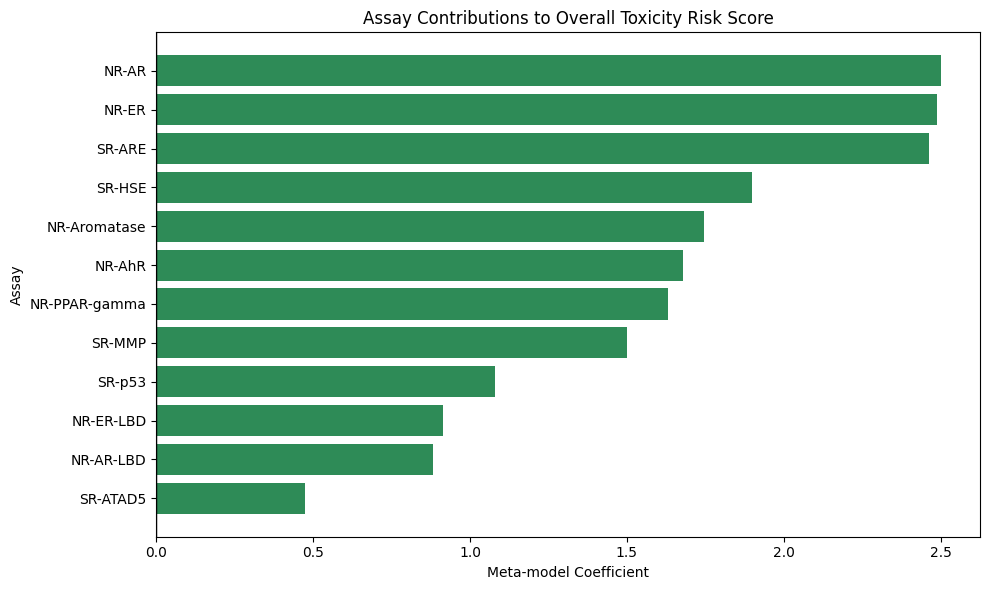

Saved: ../../../docs/meta_model_coefficients.png

Top 3 positive coefficients (most predictive of higher risk):
- NR-AR (2.5003)
- NR-ER (2.4887)
- SR-ARE (2.4640)

Top 3 negative coefficients (most predictive of lower risk):
- SR-ATAD5 (0.4736)
- NR-AR-LBD (0.8833)
- NR-ER-LBD (0.9139)


In [20]:
if 'final_meta' not in globals():
    if os.path.exists(f'{MODELS_DIR}meta_model.joblib'):
        loaded_meta = joblib.load(f'{MODELS_DIR}meta_model.joblib')
        if hasattr(loaded_meta, 'calibrated_classifiers_') and loaded_meta.calibrated_classifiers_:
            final_meta = loaded_meta.calibrated_classifiers_[0].estimator
        else:
            final_meta = loaded_meta
    else:
        raise FileNotFoundError('meta_model.joblib not found. Run final meta-model training cell first.')

coefficients = final_meta.coef_[0]
coef_df = pd.DataFrame({
    'assay': ASSAY_COLUMNS,
    'coefficient': coefficients
}).sort_values('coefficient', ascending=False)

print('Assay coefficients (positive = increases overall risk):')
for _, row in coef_df.iterrows():
    print(f"{row['assay']}: {row['coefficient']:.4f}")

plt.figure(figsize=(10, 6))
plot_df = coef_df.sort_values('coefficient', ascending=True)
colors = ['firebrick' if c < 0 else 'seagreen' for c in plot_df['coefficient']]
plt.barh(plot_df['assay'], plot_df['coefficient'], color=colors)
plt.axvline(0.0, color='black', linewidth=1)
plt.title('Assay Contributions to Overall Toxicity Risk Score')
plt.xlabel('Meta-model Coefficient')
plt.ylabel('Assay')
plt.tight_layout()
plt.savefig('../../../docs/meta_model_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: ../../../docs/meta_model_coefficients.png')

print('\nTop 3 positive coefficients (most predictive of higher risk):')
for _, row in coef_df.head(3).iterrows():
    print(f"- {row['assay']} ({row['coefficient']:.4f})")

print('\nTop 3 negative coefficients (most predictive of lower risk):')
for _, row in coef_df.tail(3).sort_values('coefficient').iterrows():
    print(f"- {row['assay']} ({row['coefficient']:.4f})")

## Cell 7 - Validate on Known Compounds

In [21]:
known_compounds = {
    "Aspirin": "CC(=O)OC1=CC=CC=C1C(=O)O",
    "Pyrene": "c1ccc2c(c1)ccc3c2ccc4c3cccc4",
    "Caffeine": "Cn1cnc2n(C)c(=O)n(C)c(=O)c12",
    "Tamoxifen": "CC/C(=C(/C1=CC=CC=C1)\\C1=CC=CC=C1)/C1=CC=C(OCCN(C)C)C=C1",
}

if 'calibrated_meta' not in globals():
    meta_model_path = f"{MODELS_DIR}meta_model.joblib"
    if not os.path.exists(meta_model_path):
        raise FileNotFoundError('meta_model.joblib not found. Run final meta-model training cell first.')
    calibrated_meta = joblib.load(meta_model_path)

base_models = load_base_models(ASSAY_COLUMNS, MODELS_DIR)

results = []
for name, smi in known_compounds.items():
    feat = np.asarray(extract_features(smi), dtype=np.float32).reshape(1, -1)

    base_probs = []
    for assay in ASSAY_COLUMNS:
        p = float(base_models[assay].predict_proba(feat)[0, 1])
        base_probs.append(p)

    base_probs_arr = np.asarray(base_probs, dtype=np.float32).reshape(1, -1)
    stacked_prob = float(calibrated_meta.predict_proba(base_probs_arr)[0, 1])

    top_assay_idx = int(np.argmax(base_probs_arr[0]))
    results.append({
        "compound": name,
        "stacked_toxic_probability": stacked_prob,
        "most_toxic_assay": ASSAY_COLUMNS[top_assay_idx],
        "most_toxic_assay_probability": float(base_probs_arr[0, top_assay_idx]),
    })

results_df = pd.DataFrame(results).sort_values("stacked_toxic_probability", ascending=False)
display(results_df)

for _, row in results_df.iterrows():
    print(
        f"{row['compound']}: overall_toxic_risk={row['stacked_toxic_probability']:.3f}, "
        f"most_toxic_assay={row['most_toxic_assay']} ({row['most_toxic_assay_probability']:.3f})"
    )

,compound,stacked_toxic_probability,most_toxic_assay,most_toxic_assay_probability
1,Pyrene,0.960183,NR-AhR,0.881245
0,Aspirin,0.793396,SR-MMP,0.810439
3,Tamoxifen,0.725644,NR-ER-LBD,0.880258
2,Caffeine,0.426894,NR-ER,0.429722


Pyrene: overall_toxic_risk=0.960, most_toxic_assay=NR-AhR (0.881)
Aspirin: overall_toxic_risk=0.793, most_toxic_assay=SR-MMP (0.810)
Tamoxifen: overall_toxic_risk=0.726, most_toxic_assay=NR-ER-LBD (0.880)
Caffeine: overall_toxic_risk=0.427, most_toxic_assay=NR-ER (0.430)


### Interpretation of Known-Compound Stacking Results

The calibrated stacking model ranks **Pyrene** as the highest-risk compound (0.960), with dominant signal from **NR-AhR**, which is consistent with its known aromatic hydrocarbon toxicity profile. **Aspirin** (0.793) and **Tamoxifen** (0.726) are predicted as moderate-to-high risk, but with different dominant assay pathways (**SR-MMP** vs **NR-ER-LBD**), suggesting assay-specific mechanisms.

**Caffeine** is the lowest-risk example in this set (0.427), though still non-trivial, indicating that this meta-model may be conservative in risk aggregation. Overall, this small sanity set shows sensible ranking behavior (Pyrene > Aspirin/Tamoxifen > Caffeine), while highlighting the value of reporting both **overall stacked risk** and **top contributing assay probability** for interpretation.

## Cell 8 - Update Model Registry

In [22]:
registry_path = Path("../processed/model_registry.json")

if registry_path.exists():
    with open(registry_path, "r", encoding="utf-8") as f:
        registry = json.load(f)
else:
    registry = {}

registry["meta_model"] = {
    "type": "logistic_regression + isotonic_calibration",
    "file": "meta_model.joblib",
    "input_features": "12 base assay probabilities",
    "cross_val_auc": float(meta_auc) if "meta_auc" in globals() else None,
}
registry["meta_model_assay_order"] = ASSAY_COLUMNS

with open(registry_path, "w", encoding="utf-8") as f:
    json.dump(registry, f, indent=2)

print(f"Updated model registry: {registry_path}")
print(json.dumps(registry.get("meta_model", {}), indent=2))

Updated model registry: ../processed/model_registry.json
{
  "type": "logistic_regression + isotonic_calibration",
  "file": "meta_model.joblib",
  "input_features": "12 base assay probabilities",
  "cross_val_auc": 0.9162811235979039
}
